#### Overview
This notebook demonstrates a cloud based approach to geospatial data procurement. Instead of downloading static, multi-gigabyte global datasets, I built a dynamic pipeline using the Google Earth Engine (GEE) Python API to extract 10 m-resolution cropland data for the state of Karnataka, India.

In [19]:
import ee
import geemap

# This opens the login page where we need to copy the athenticated code
ee.Authenticate()

Enter verification code:  4/1AfrIepAUccx3apB7Mx2ks_5cN1Z_wI2N5XV6pdE-JxVRJFAknRBUi5BJvg8



Successfully saved authorization token.


In [27]:
# Import Earth Engine and paste your project ID (created earlier in Google Cloud) here
import ee
ee.Initialize(project='karnataka-agripv-project')
print("Connection Complete!")

Connection Complete!


In [85]:
import os

# Load a dataset from Earth Engine called GAUL (Global Administrative Unit Layers) provided by FAO. 
# "level1" = state-level boundaries and Filter for Karnataka.
india_states = ee.FeatureCollection("FAO/GAUL/2015/level1")
karnataka = india_states.filter(ee.Filter.eq('ADM1_NAME', 'Karnataka'))

# Load ESA WorldCover as one global image (.first())
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first()

# Clip boundary for Karnataka and Cropland mask (Class 40)
cropland_mask = worldcover.eq(40).clip(karnataka)

# Define output filename
output_file = "karnataka_cropland_new.tif"

# Just to confirm the file is exporting
print(f"Starting export for {output_file}...")

# Export locally using geemap
geemap.ee_export_image(
    cropland_mask,
    filename=output_file,
    scale=150,  # keep 150m for faster export; use 10 for full resolution
    region=karnataka.geometry(),  # ✅ THIS is the key fix
    file_per_band=False
)

# Check if file exists
if os.path.exists(output_file):
    print(f"✅ Success! {output_file} is now in your folder.")
else:
    print("⏳ Exporting... check your folder in 30–60 seconds.")

Starting export for karnataka_cropland_new.tif...
Generating URL ...
Please wait ...
Data downloaded to /Users/soujanyakrishnamurthy/karnataka_cropland_new.tif
✅ Success! karnataka_cropland_new.tif is now in your folder.


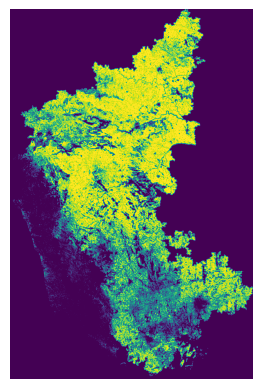

In [87]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("karnataka_cropland_new.tif")
plt.imshow(img)
plt.axis('off')
plt.show()